<a href="https://colab.research.google.com/github/nabajyotigoswami/MD-analysis/blob/main/ML-PCA-RF_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import required libraries
import pandas as pd

# Upload Excel files (Google Colab)
from google.colab import files

uploaded = files.upload()

Saving Hbonds-WT-replicate-and-R194W.xlsx to Hbonds-WT-replicate-and-R194W.xlsx
Saving numcont-WT-replicate-and-R194W.xlsx to numcont-WT-replicate-and-R194W.xlsx
Saving Rg-WT-replicate-and-R194W.xlsx to Rg-WT-replicate-and-R194W.xlsx
Saving RMSD-WT-replicate-and-R194W.xlsx to RMSD-WT-replicate-and-R194W.xlsx
Saving SASA-WT-replicate-and-R194W.xlsx to SASA-WT-replicate-and-R194W.xlsx


In [ ]:
!pip install scikit-posthocs

In [ ]:
rmsd = pd.read_excel("RMSD-WT-replicate-and-R194W.xlsx")
rg = pd.read_excel("Rg-WT-replicate-and-R194W.xlsx")
sasa = pd.read_excel("SASA-WT-replicate-and-R194W.xlsx")
numcont = pd.read_excel("numcont-WT-replicate-and-R194W.xlsx")
hbnum = pd.read_excel("Hbonds-WT-replicate-and-R194W.xlsx")

In [ ]:
print(rmsd.head())

   Time  XRCC1WT-ligIIIa  XRCC1WT-polB  XRCC1R194W-ligIIIa  XRCC1R194W-polB
0  0.00         0.000016      0.000005            0.000032         0.000032
1  0.01         0.090005      0.091767            0.100151         0.095604
2  0.02         0.099867      0.118145            0.119307         0.105309
3  0.03         0.104236      0.134725            0.133459         0.121191
4  0.04         0.102480      0.130065            0.136215         0.118705


In [ ]:
def block_average(series, block_size):

    n_blocks = len(series) // block_size

    means = []

    for i in range(n_blocks):

        start = i*block_size
        end = (i+1)*block_size

        means.append(series[start:end].mean())

    return np.array(means)

In [ ]:
block_size = 100

In [ ]:
def prepare_blocks(df):

    sim1 = block_average(df["Sim1"], block_size)
    sim2 = block_average(df["Sim2"], block_size)
    sim3 = block_average(df["Sim3"], block_size)
    sim4 = block_average(df["Sim4"], block_size)

    return sim1, sim2, sim3, sim4

In [ ]:
def prepare_blocks(df):

    XRCC1WT-ligIIIa = block_average(df["XRCC1WT-ligIIIa"], block_size)
    XRCC1WT-polB = block_average(df["XRCC1WT-polB"], block_size)
    XRCC1R194W-ligIIIa = block_average(df["XRCC1R194W-ligIIIa"], block_size)
    XRCC1R194W-polB = block_average(df["XRCC1R194W-polB"], block_size)

    return XRCC1WT-ligIIIa, XRCC1WT-polB, XRCC1R194W-ligIIIa, XRCC1R194W-polB

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (3240314543.py, line 3)

In [ ]:
rmsd_blocks = prepare_blocks(rmsd)

KeyError: 'Sim1'

In [ ]:
print(rmsd.columns)

Index(['Time', 'XRCC1WT-ligIIIa', 'XRCC1WT-polB', 'XRCC1R194W-ligIIIa',
       'XRCC1R194W-polB'],
      dtype='object')


In [ ]:
def prepare_blocks(df):

    # Ignore the first column (Time)
    columns = df.columns[1:]

    blocks = []

    for column in columns:

        values = block_average(df[column], block_size)
        blocks.append(values)

    return blocks

In [ ]:
def dunn_test(data, df):

    labels = list(df.columns[1:])

    all_values = []
    groups = []

    for values, label in zip(data, labels):

        all_values.extend(values)
        groups.extend([label]*len(values))

    temp_df = pd.DataFrame({

        "values": all_values,
        "groups": groups

    })

    result = sp.posthoc_dunn(
        temp_df,
        val_col='values',
        group_col='groups',
        p_adjust='bonferroni'
    )

    return result

In [ ]:
result = dunn_test(data, df)

NameError: name 'data' is not defined

In [ ]:
data = prepare_blocks(df)

NameError: name 'df' is not defined

In [ ]:
data = prepare_blocks(df)

NameError: name 'df' is not defined

In [ ]:
data = prepare_blocks(rmsd)

In [ ]:
data = prepare_blocks(rg)

In [ ]:
data = prepare_blocks(sasa)

In [ ]:
def block_average(series, block_size):

    n_blocks = len(series) // block_size

    means = []

    for i in range(n_blocks):

        start = i * block_size
        end = (i + 1) * block_size

        means.append(series.iloc[start:end].mean())

    return np.array(means)

In [ ]:
def prepare_blocks(df):

    columns = df.columns[1:]   # skip Time column

    blocks = []

    for column in columns:

        values = block_average(df[column], block_size)
        blocks.append(values)

    return blocks

In [ ]:
block_size = 100

In [ ]:
rmsd_blocks = prepare_blocks(rmsd)

print(len(rmsd_blocks))

4


In [ ]:
print(rmsd_blocks[0])

[0.15437881 0.20103603 0.2247445  0.21973023 0.24075511 0.20894309
 0.23408558 0.215253   0.22646182 0.2216088  0.2614876  0.29269364
 0.27780819 0.31594983 0.28782653 0.27092048 0.27791718 0.33849598
 0.30195692 0.26767914 0.25686216 0.27140083 0.28337462 0.28745426
 0.28135592 0.28999246 0.29952464 0.30007948 0.34696298 0.36297022
 0.34958986 0.3221944  0.30497395 0.30960876 0.33125591 0.28916127
 0.28701664 0.26941011 0.29802032 0.29690228 0.27712781 0.27778323
 0.27997181 0.28248452 0.3124367  0.34333354 0.34185668 0.34798331
 0.31647026 0.32906906 0.3552364  0.35010001 0.34430035 0.3754051
 0.35233829 0.36154384 0.34098989 0.35316741 0.36919616 0.34356724
 0.34853413 0.36392068 0.3446187  0.34923426 0.38187895 0.38945484
 0.45211482 0.43839293 0.40977662 0.39529517 0.39127055 0.39666345
 0.45936074 0.43298338 0.44000894 0.48564368 0.49222362 0.51015866
 0.51721894 0.48204643 0.51185707 0.51329309 0.50813516 0.50853983
 0.48827786 0.50829637 0.49591026 0.45433743 0.49790898 0.42708

In [ ]:
p = kruskal_test(rmsd_blocks)

NameError: name 'kruskal_test' is not defined

In [ ]:
# Import required statistical function
from scipy.stats import kruskal

# Define Kruskal-Wallis test function

def kruskal_test(data):

    statistic, p_value = kruskal(*data)

    print("Kruskal-Wallis statistic:", statistic)
    print("p-value:", p_value)

    return p_value

In [ ]:
p = kruskal_test(rmsd_blocks)

Kruskal-Wallis statistic: 457.3078358034968
p-value: 8.508561721361714e-99


In [ ]:
# Install if not already installed
!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp
import pandas as pd


def dunn_test(data, df):

    labels = list(df.columns[1:])   # simulation names

    values = []
    groups = []

    for arr, label in zip(data, labels):

        values.extend(arr)
        groups.extend([label]*len(arr))


    temp = pd.DataFrame({
        "RMSD": values,
        "Simulation": groups
    })


    result = sp.posthoc_dunn(
        temp,
        val_col="RMSD",
        group_col="Simulation",
        p_adjust="bonferroni"
    )

    return result


dunn_results = dunn_test(rmsd_blocks, rmsd)

dunn_results

,XRCC1R194W-ligIIIa,XRCC1R194W-polB,XRCC1WT-ligIIIa,XRCC1WT-polB
XRCC1R194W-ligIIIa,1.000000e+00,1.239032e-05,2.917562e-38,3.111985e-85
XRCC1R194W-polB,1.239032e-05,1.000000e+00,5.127568e-16,1.739706e-49
XRCC1WT-ligIIIa,2.917562e-38,5.127568e-16,1.000000e+00,2.726835e-10
XRCC1WT-polB,3.111985e-85,1.739706e-49,2.726835e-10,1.000000e+00


In [ ]:
rg_blocks = prepare_blocks(rg)
kruskal_test(rg_blocks)

sasa_blocks = prepare_blocks(sasa)
kruskal_test(sasa_blocks)

numcont_blocks = prepare_blocks(numcont)
kruskal_test(numcont_blocks)

hbnum_blocks = prepare_blocks(hbnum)
kruskal_test(hbnum_blocks)

Kruskal-Wallis statistic: 864.1859593116851
p-value: 5.189775946795543e-187
Kruskal-Wallis statistic: 728.0523221204548
p-value: 1.7340580485507976e-157
Kruskal-Wallis statistic: 135.5087235974549
p-value: 3.513568372890065e-29
Kruskal-Wallis statistic: 645.1340649970464
p-value: 1.6533104749544993e-139


np.float64(1.6533104749544993e-139)

In [ ]:
rg_blocks = prepare_blocks(rg)
kruskal_test(rg_blocks)

sasa_blocks = prepare_blocks(sasa)
kruskal_test(sasa_blocks)

numcont_blocks = prepare_blocks(numcont)
kruskal_test(numcont_blocks)

hbnum_blocks = prepare_blocks(hbnum)
kruskal_test(hbnum_blocks)

Kruskal-Wallis statistic: 864.1859593116851
p-value: 5.189775946795543e-187
Kruskal-Wallis statistic: 728.0523221204548
p-value: 1.7340580485507976e-157
Kruskal-Wallis statistic: 135.5087235974549
p-value: 3.513568372890065e-29
Kruskal-Wallis statistic: 645.1340649970464
p-value: 1.6533104749544993e-139


np.float64(1.6533104749544993e-139)

In [ ]:
rg_dunn = dunn_test(rg_blocks, rg)
rg_dunn

,XRCC1R194W-ligIII,XRCC1R194W-polB,XRCC1WT-ligIIIa,XRCC1WT-polB
XRCC1R194W-ligIII,1.000000e+00,5.914030e-42,4.042692e-43,1.400931e-15
XRCC1R194W-polB,5.914030e-42,1.000000e+00,7.109775e-167,2.296304e-07
XRCC1WT-ligIIIa,4.042692e-43,7.109775e-167,1.000000e+00,1.935573e-107
XRCC1WT-polB,1.400931e-15,2.296304e-07,1.935573e-107,1.000000e+00


In [ ]:
sasa_dunn = dunn_test(sasa_blocks, sasa)
sasa_dunn

,XRCC1R194W-ligIII,XRCC1R194W-polB,XRCC1WT-ligIII,XRCC1WT-polB
XRCC1R194W-ligIII,1.000000e+00,7.223730e-13,2.196840e-66,1.793297e-04
XRCC1R194W-polB,7.223730e-13,1.000000e+00,2.995424e-134,7.120882e-03
XRCC1WT-ligIII,2.196840e-66,2.995424e-134,1.000000e+00,1.190429e-101
XRCC1WT-polB,1.793297e-04,7.120882e-03,1.190429e-101,1.000000e+00


In [ ]:
numcont_dunn = dunn_test(numcont_blocks, numcont)
numcont_dunn

,XRCC1R194W-LigIII,XRCC1R194W-PolB,XRCC1WT-LigIII,XRCC1WT-PolB
XRCC1R194W-LigIII,1.000000e+00,2.317743e-29,7.823363e-07,7.310936e-13
XRCC1R194W-PolB,2.317743e-29,1.000000e+00,5.319571e-09,3.928864e-04
XRCC1WT-LigIII,7.823363e-07,5.319571e-09,1.000000e+00,1.958525e-01
XRCC1WT-PolB,7.310936e-13,3.928864e-04,1.958525e-01,1.000000e+00


In [ ]:
hbnum_dunn = dunn_test(hbnum_blocks, hbnum)
hbnum_dunn

,XRCC1R194W-LigIII,XRCC1R194W-PolB,XRCC1WT-LigIII,XRCC1WT-PolB
XRCC1R194W-LigIII,1.000000e+00,1.418433e-64,1.096047e-08,6.311933e-115
XRCC1R194W-PolB,1.418433e-64,1.000000e+00,1.172212e-27,4.185353e-08
XRCC1WT-LigIII,1.096047e-08,1.172212e-27,1.000000e+00,6.101500e-63
XRCC1WT-PolB,6.311933e-115,4.185353e-08,6.101500e-63,1.000000e+00


In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
def create_plot_dataframe(blocks, df):

    labels = list(df.columns[1:])

    values=[]
    groups=[]

    for data,label in zip(blocks,labels):

        values.extend(data)
        groups.extend([label]*len(data))

    plot_df=pd.DataFrame({
        "Value":values,
        "System":groups
    })

    return plot_df

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def create_plot_dataframe(blocks, df):

    labels = list(df.columns[1:])

    values = []
    systems = []

    for data, label in zip(blocks, labels):

        values.extend(data)
        systems.extend([label]*len(data))

    return pd.DataFrame({
        "System": systems,
        "Value": values
    })


def plot_box(blocks, df, ylabel, title):

    plot_df = create_plot_dataframe(blocks, df)

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=plot_df,
        x="System",
        y="Value",
        width=0.5
    )

    sns.stripplot(
        data=plot_df,
        x="System",
        y="Value",
        size=4,
        alpha=0.6
    )

    plt.xlabel("")
    plt.ylabel(ylabel)

    plt.title(title)

    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    plt.show()

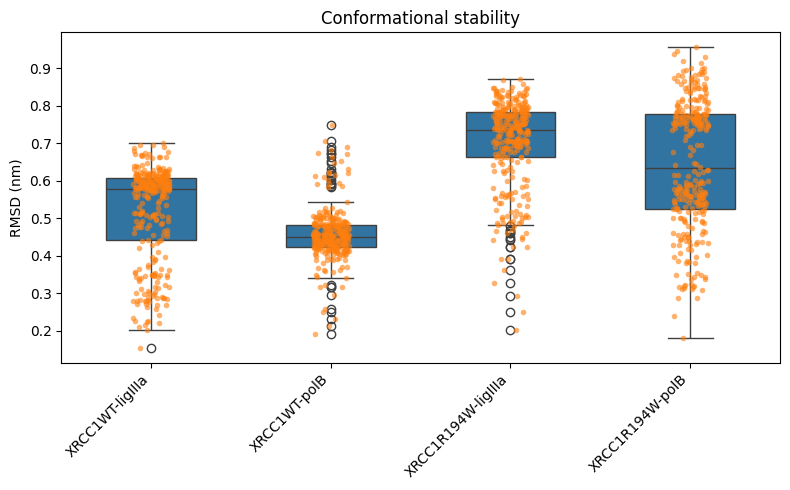

In [ ]:
plot_box(
    rmsd_blocks,
    rmsd,
    "RMSD (nm)",
    "Conformational stability"
)

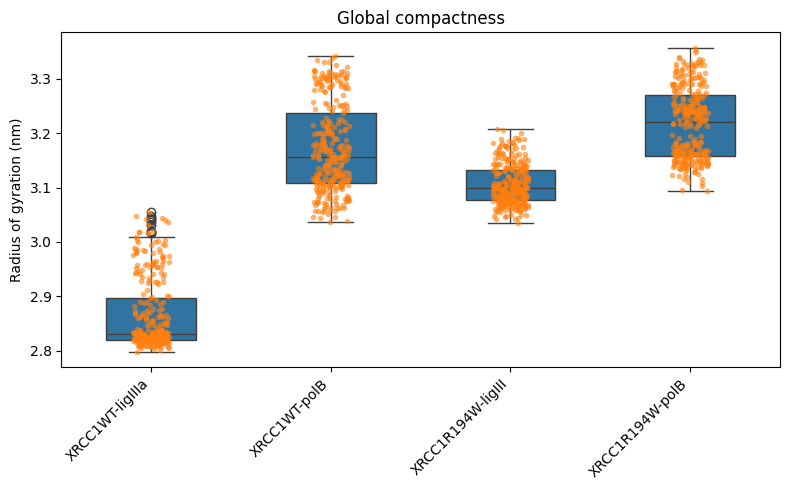

In [ ]:
plot_box(
    rg_blocks,
    rg,
    "Radius of gyration (nm)",
    "Global compactness"
)

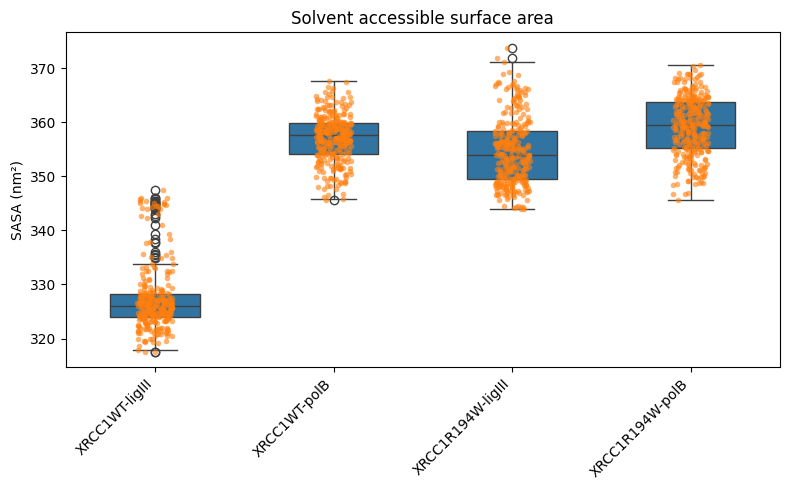

In [ ]:
plot_box(
    sasa_blocks,
    sasa,
    "SASA (nm²)",
    "Solvent accessible surface area"
)

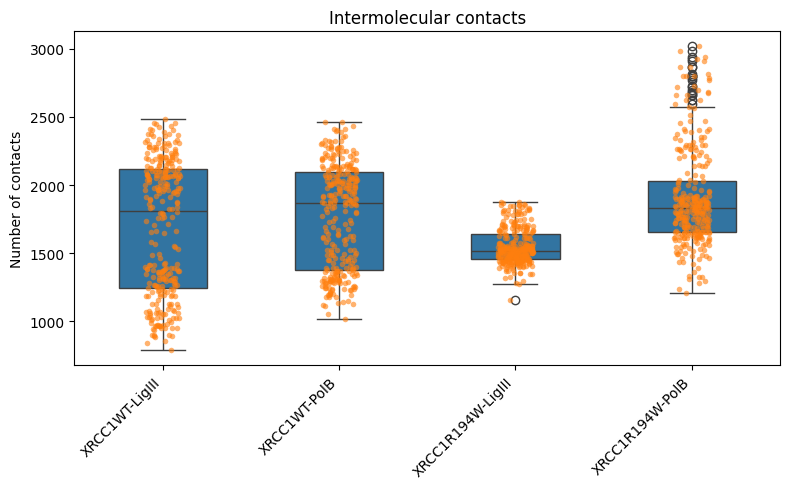

In [ ]:
plot_box(
    numcont_blocks,
    numcont,
    "Number of contacts",
    "Intermolecular contacts"
)

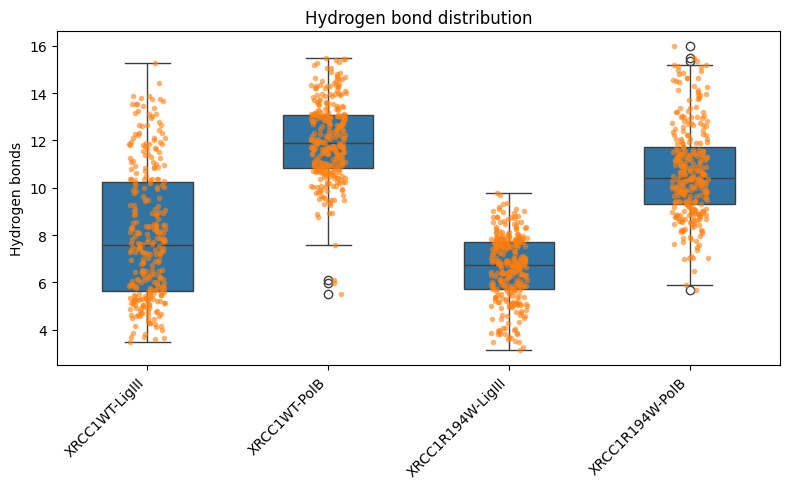

In [ ]:
plot_box(
    hbnum_blocks,
    hbnum,
    "Hydrogen bonds",
    "Hydrogen bond distribution"
)

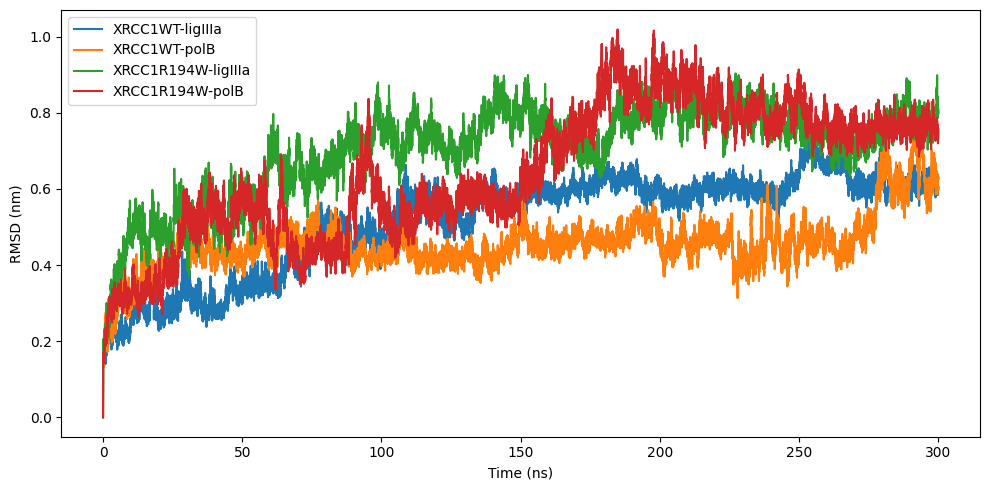

In [ ]:
plt.figure(figsize=(10,5))

for column in rmsd.columns[1:]:

    plt.plot(
        rmsd["Time"],
        rmsd[column],
        label=column
    )

plt.xlabel("Time (ns)")
plt.ylabel("RMSD (nm)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
rmsd_dunn
rg_dunn
sasa_dunn
numcont_dunn
hbnum_dunn

NameError: name 'rmsd_dunn' is not defined

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Hbonds-WT-replicate-and-R194W.xlsx to Hbonds-WT-replicate-and-R194W (1).xlsx
Saving numcont-WT-replicate-and-R194W.xlsx to numcont-WT-replicate-and-R194W (1).xlsx
Saving Rg-WT-replicate-and-R194W.xlsx to Rg-WT-replicate-and-R194W (1).xlsx
Saving RMSD-WT-replicate-and-R194W.xlsx to RMSD-WT-replicate-and-R194W (1).xlsx
Saving SASA-WT-replicate-and-R194W.xlsx to SASA-WT-replicate-and-R194W (1).xlsx
Saving SA-WT-replicate-and-R194W.xlsx to SA-WT-replicate-and-R194W.xlsx


In [ ]:
import pandas as pd

In [ ]:
def convert_to_500ps(input_file, output_file):

    df = pd.read_excel(input_file)

    # Select rows where time is multiple of 500 ps
    df_500 = df[df.iloc[:,0] % 500 == 0]

    # Save output
    df_500.to_excel(output_file, index=False)

    print(input_file, "converted")
    print("Original rows:", len(df))
    print("New rows:", len(df_500))

    return df_500

In [ ]:
rmsd_500 = convert_to_500ps(
    "RMSD-WT-replicate-and-R194W.xlsx",
    "RMSD_500ps.xlsx"
)

RMSD-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
rg_500 = convert_to_500ps(
    "Rg-WT-replicate-and-R194W.xlsx",
    "Rg_500ps.xlsx"
)

Rg-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
sasa_500 = convert_to_500ps(
    "SASA-WT-replicate-and-R194W.xlsx",
    "SASA_500ps.xlsx"
)

SASA-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
numcont_500 = convert_to_500ps(
    "numcont-WT-replicate-and-R194W.xlsx",
    "Numcont_500ps.xlsx"
)

numcont-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
hbnum_500 = convert_to_500ps(
    "Hbonds-WT-replicate-and-R194W.xlsx",
    "hbnum_500ps.xlsx"
)

Hbonds-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
from google.colab import files

files.download("RMSD_500ps.xlsx")
files.download("Rg_500ps.xlsx")
files.download("SASA_500ps.xlsx")
files.download("Numcont_500ps.xlsx")
files.download("hbnum_500ps.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving RMSD-WT-replicate-and-R194W.xlsx to RMSD-WT-replicate-and-R194W.xlsx


In [ ]:
!ls -l

total 6020
-rw-r--r-- 1 root root   18155 Jul 30 15:29 0.5ns_Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   21646 Jul 30 15:29 0.5ns_numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   24829 Jul 30 15:29 0.5ns_Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   25367 Jul 30 15:29 0.5ns_SASA-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36845 Jul 30 15:11 DGbind-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5004 Jul 30 15:20 hbnum_500ps.xlsx
-rw-r--r-- 1 root root  750001 Jul 30 15:13 Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36717 Jul 30 15:11 MM-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5011 Jul 30 15:20 Numcont_500ps.xlsx
-rw-r--r-- 1 root root  994085 Jul 30 15:13 numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   35894 Jul 30 15:11 PB-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5022 Jul 30 15:20 Rg_500ps.xlsx
-rw-r--r-- 1 root root 1287198 Jul 30 15:13 Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns

In [ ]:
def convert_to_500ps(input_file, output_file):

    df = pd.read_excel(input_file)

    # Select rows where time is multiple of 500 ps
    df_500 = df[df.iloc[:,0] % 500 == 0]

    # Save output
    df_500.to_excel(output_file, index=False)

    print(input_file, "converted")
    print("Original rows:", len(df))
    print("New rows:", len(df_500))

    return df_500

In [ ]:
rmsd_500 = convert_to_500ps(
    "RMSD-WT-replicate-and-R194W.xlsx",
    "RMSD_500ps.xlsx"
)

rg_500 = convert_to_500ps(
    "Rg-WT-replicate-and-R194W.xlsx",
    "Rg_500ps.xlsx"
)

sasa_500 = convert_to_500ps(
    "SASA-WT-replicate-and-R194W.xlsx",
    "SASA_500ps.xlsx"
)

numcont_500 = convert_to_500ps(
    "numcont-WT-replicate-and-R194W.xlsx",
    "Numcont_500ps.xlsx"
)

hbnum_500 = convert_to_500ps(
    "Hbonds-WT-replicate-and-R194W.xlsx",
    "hbnum_500ps.xlsx"
)

RMSD-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1
Rg-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1
SASA-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1
numcont-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1
Hbonds-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
rmsd_500 = convert_to_500ps(
    "RMSD-WT-replicate-and-R194W.xlsx",
    "RMSD_500ps.xlsx"
)

RMSD-WT-replicate-and-R194W.xlsx converted
Original rows: 30001
New rows: 1


In [ ]:
import pandas as pd
import os

# Files to be converted
files = [
    "RMSD-WT-replicate-and-R194W.xlsx",
    "Rg-WT-replicate-and-R194W.xlsx",
    "SASA-WT-replicate-and-R194W.xlsx",
    "Hbonds-WT-replicate-and-R194W.xlsx",
    "numcont-WT-replicate-and-R194W.xlsx"
]

for file in files:

    # Read the Excel file
    df = pd.read_excel(file)

    # Assume first column contains time values in ns
    time_col = df.columns[0]

    # Keep only rows at every 0.5 ns
    df_filtered = df[df[time_col] % 0.5 == 0]

    # Output filename
    out_file = "0.5ns_" + file

    # Save
    df_filtered.to_excel(out_file, index=False)

    print(f"Saved: {out_file}")

Saved: 0.5ns_RMSD-WT-replicate-and-R194W.xlsx
Saved: 0.5ns_Rg-WT-replicate-and-R194W.xlsx
Saved: 0.5ns_SASA-WT-replicate-and-R194W.xlsx
Saved: 0.5ns_Hbonds-WT-replicate-and-R194W.xlsx
Saved: 0.5ns_numcont-WT-replicate-and-R194W.xlsx


In [ ]:
import pandas as pd

files = [
    "0.5ns_RMSD-WT-replicate-and-R194W.xlsx",
    "0.5ns_Rg-WT-replicate-and-R194W.xlsx",
    "0.5ns_SASA-WT-replicate-and-R194W.xlsx",
    "0.5ns_Hbonds-WT-replicate-and-R194W.xlsx",
    "0.5ns_numcont-WT-replicate-and-R194W.xlsx"
]

for file in files:
    df = pd.read_excel(file)
    print(file, ":", len(df))

0.5ns_RMSD-WT-replicate-and-R194W.xlsx : 601
0.5ns_Rg-WT-replicate-and-R194W.xlsx : 601
0.5ns_SASA-WT-replicate-and-R194W.xlsx : 601
0.5ns_Hbonds-WT-replicate-and-R194W.xlsx : 601
0.5ns_numcont-WT-replicate-and-R194W.xlsx : 601


In [ ]:
import pandas as pd

df = pd.read_excel("RMSD-WT-replicate-and-R194W.xlsx")

print(df.head(20))
print()
print(df.tail(20))
print()
print(df.columns)

    Time  XRCC1WT-ligIIIa  XRCC1WT-polB  XRCC1R194W-ligIIIa  XRCC1R194W-polB
0   0.00         0.000016      0.000005            0.000032         0.000032
1   0.01         0.090005      0.091767            0.100151         0.095604
2   0.02         0.099867      0.118145            0.119307         0.105309
3   0.03         0.104236      0.134725            0.133459         0.121191
4   0.04         0.102480      0.130065            0.136215         0.118705
5   0.05         0.115424      0.135199            0.153274         0.127770
6   0.06         0.138641      0.134480            0.161018         0.129976
7   0.07         0.125358      0.137241            0.162150         0.154804
8   0.08         0.132169      0.135590            0.166965         0.151177
9   0.09         0.146718      0.134810            0.175193         0.157933
10  0.10         0.141941      0.134281            0.168261         0.153987
11  0.11         0.151974      0.138934            0.170390         0.171236

In [ ]:
print(df.shape)

(30001, 5)


In [ ]:
time_col = df.columns[0]

print(df[time_col].min())
print(df[time_col].max())

0.0
300.0


In [ ]:
print(df.iloc[:20,0].tolist())

[0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19]


In [ ]:
import numpy as np

time = df.iloc[:,0]

print(np.unique(np.diff(time))[:20])

[0.0099792 0.0099792 0.0099793 0.0099945 0.0099945 0.0099945 0.0099946
 0.0099983 0.0099983 0.0099983 0.0099984 0.0099984 0.0099992 0.0099993
 0.0099993 0.0099997 0.0099997 0.0099998 0.0099998 0.0099999]


In [ ]:
df_filtered = df[np.isclose(df[time_col] % 0.5, 0, atol=1e-6)]

In [ ]:
df[time_col] = df[time_col].round(2)

df_filtered = df[df[time_col] % 0.5 == 0]

In [ ]:
df[time_col] = df[time_col].round(3)

In [ ]:
desired_time = [i*0.5 for i in range(601)]

df_filtered = df[df[time_col].round(3).isin(desired_time)]

In [ ]:
!ls -l

total 6072
-rw-r--r-- 1 root root   18155 Jul 30 15:29 0.5ns_Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   21646 Jul 30 15:29 0.5ns_numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   24829 Jul 30 15:29 0.5ns_Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   13697 Jul 30 15:29 0.5ns_RMSD-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   25367 Jul 30 15:29 0.5ns_SASA-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36845 Jul 30 15:11 DGbind-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5004 Jul 30 15:20 hbnum_500ps.xlsx
-rw-r--r-- 1 root root  750001 Jul 30 15:13 Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36717 Jul 30 15:11 MM-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5011 Jul 30 15:20 Numcont_500ps.xlsx
-rw-r--r-- 1 root root  994085 Jul 30 15:13 numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   35894 Jul 30 15:11 PB-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5022 Jul 30 15:20 Rg_500ps.xlsx
-

In [ ]:
!rm -rf RMSD-WT-replicate-and-R194W.xlsx

In [ ]:
!ls -l

total 4552
-rw-r--r-- 1 root root   18155 Jul 30 15:29 0.5ns_Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   21646 Jul 30 15:29 0.5ns_numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   24829 Jul 30 15:29 0.5ns_Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   25367 Jul 30 15:29 0.5ns_SASA-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36845 Jul 30 15:11 DGbind-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5004 Jul 30 15:20 hbnum_500ps.xlsx
-rw-r--r-- 1 root root  750001 Jul 30 15:13 Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36717 Jul 30 15:11 MM-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5011 Jul 30 15:20 Numcont_500ps.xlsx
-rw-r--r-- 1 root root  994085 Jul 30 15:13 numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   35894 Jul 30 15:11 PB-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5022 Jul 30 15:20 Rg_500ps.xlsx
-rw-r--r-- 1 root root 1287198 Jul 30 15:13 Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_excel("0.5ns_RMSD-WT-replicate-and-R194W.xlsx")

time_col = df.columns[0]

intervals = np.diff(df[time_col])

print(np.unique(intervals))

[0.5]


In [ ]:
original = pd.read_excel("RMSD-WT-replicate-and-R194W.xlsx")
new = pd.read_excel("0.5ns_RMSD-WT-replicate-and-R194W.xlsx")

print(original.head(60))
print()
print(new.head(5))

    Time  XRCC1WT-ligIIIa  XRCC1WT-polB  XRCC1R194W-ligIIIa  XRCC1R194W-polB
0   0.00         0.000016      0.000005            0.000032         0.000032
1   0.01         0.090005      0.091767            0.100151         0.095604
2   0.02         0.099867      0.118145            0.119307         0.105309
3   0.03         0.104236      0.134725            0.133459         0.121191
4   0.04         0.102480      0.130065            0.136215         0.118705
5   0.05         0.115424      0.135199            0.153274         0.127770
6   0.06         0.138641      0.134480            0.161018         0.129976
7   0.07         0.125358      0.137241            0.162150         0.154804
8   0.08         0.132169      0.135590            0.166965         0.151177
9   0.09         0.146718      0.134810            0.175193         0.157933
10  0.10         0.141941      0.134281            0.168261         0.153987
11  0.11         0.151974      0.138934            0.170390         0.171236

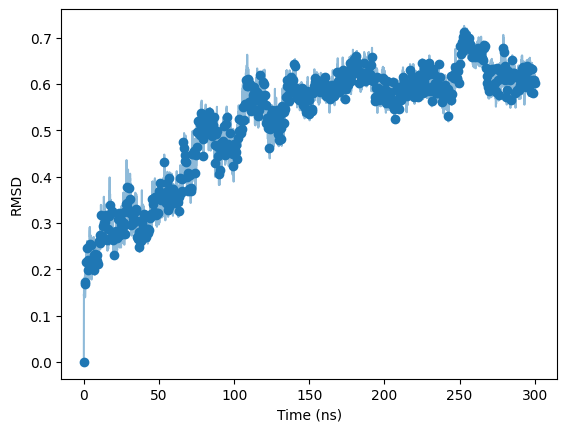

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

original = pd.read_excel("RMSD-WT-replicate-and-R194W.xlsx")
new = pd.read_excel("0.5ns_RMSD-WT-replicate-and-R194W.xlsx")

time1 = original.iloc[:,0]
y1 = original.iloc[:,1]

time2 = new.iloc[:,0]
y2 = new.iloc[:,1]

plt.plot(time1, y1, alpha=0.5)
plt.scatter(time2, y2)

plt.xlabel("Time (ns)")
plt.ylabel("RMSD")
plt.show()

In [ ]:
!ls -l

total 6048
-rw-r--r-- 1 root root   18154 Jul 30 15:50 0.5ns_Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   21646 Jul 30 15:50 0.5ns_numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   24828 Jul 30 15:50 0.5ns_Rg-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   28123 Jul 30 15:50 0.5ns_RMSD-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   25366 Jul 30 15:50 0.5ns_SASA-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36845 Jul 30 15:11 DGbind-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5004 Jul 30 15:20 hbnum_500ps.xlsx
-rw-r--r-- 1 root root  750001 Jul 30 15:13 Hbonds-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   36717 Jul 30 15:11 MM-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5011 Jul 30 15:20 Numcont_500ps.xlsx
-rw-r--r-- 1 root root  994085 Jul 30 15:13 numcont-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root   35894 Jul 30 15:11 PB-WT-replicate-and-R194W.xlsx
-rw-r--r-- 1 root root    5022 Jul 30 15:20 Rg_500ps.xlsx
-

In [ ]:
rmsd = pd.read_excel("0.5ns_RMSD-WT-replicate-and-R194W.xlsx")
rg = pd.read_excel("0.5ns_Rg-WT-replicate-and-R194W.xlsx")
sasa = pd.read_excel("0.5ns_SASA-WT-replicate-and-R194W.xlsx")
contacts = pd.read_excel("0.5ns_numcont-WT-replicate-and-R194W.xlsx")
hbonds = pd.read_excel("0.5ns_Hbonds-WT-replicate-and-R194W.xlsx")
MM = pd.read_excel("MM-WT-replicate-and-R194W.xlsx")
PB = pd.read_excel("PB-WT-replicate-and-R194W.xlsx")
SA = pd.read_excel("SA-WT-replicate-and-R194W.xlsx")
DG = pd.read_excel("DGbind-WT-replicate-and-R194W.xlsx")

In [ ]:
print(rmsd.columns)
print(DG.columns)

Index(['Time', 'XRCC1WT-ligIIIa', 'XRCC1WT-polB', 'XRCC1R194W-ligIIIa',
       'XRCC1R194W-polB'],
      dtype='object')
Index(['Time', 'XRCC1WT-LigIII', 'XRCC1WT-PolB', 'XRCC1R194W-LigIII',
       'XRCC1R194W-PolB'],
      dtype='object')


In [ ]:
def standardize_columns(df):

    df.columns = (
        df.columns
        .str.replace("LigIIIaa", "LigIIIa", regex=False)
    )

    return df

In [ ]:
rmsd = standardize_columns(rmsd)
rg = standardize_columns(rg)
sasa = standardize_columns(sasa)
contacts = standardize_columns(contacts)
hbonds = standardize_columns(hbonds)

MM = standardize_columns(MM)
PB = standardize_columns(PB)
SA = standardize_columns(SA)
DG = standardize_columns(DG)

In [ ]:
print(rmsd.columns)
print(DG.columns)

Index(['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa',
       'XRCC1R194W-PolB'],
      dtype='object')
Index(['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa',
       'XRCC1R194W-PolB'],
      dtype='object')


In [ ]:
datasets = {
    "RMSD": rmsd,
    "Rg": rg,
    "SASA": sasa,
    "Contacts": contacts,
    "HBonds": hbonds,
    "MM": MM,
    "PB": PB,
    "SA": SA,
    "DG": DG
}

for name, data in datasets.items():
    print("\n", name)
    print(list(data.columns))


 RMSD
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 Rg
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 SASA
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 Contacts
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 HBonds
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 MM
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 PB
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 SA
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']

 DG
['Time', 'XRCC1WT-LigIIIa', 'XRCC1WT-PolB', 'XRCC1R194W-LigIIIa', 'XRCC1R194W-PolB']


In [ ]:
systems = [
    "XRCC1R194W-LigIIIa",
    "XRCC1R194W-PolB",
    "XRCC1WT-LigIIIa",
    "XRCC1WT-PolB"
]


def reshape_data(df, parameter):

    temp = df.copy()

    temp = temp.melt(
        id_vars=["Time"],
        value_vars=systems,
        var_name="System",
        value_name=parameter
    )

    return temp


df = reshape_data(rmsd,"RMSD")


for data,name in [
    (rg,"Rg"),
    (sasa,"SASA"),
    (contacts,"Contacts"),
    (hbonds,"HBonds"),
    (MM,"MM"),
    (PB,"PB"),
    (SA,"SA"),
    (DG,"DGbinding")
]:

    temp = reshape_data(data,name)

    df = df.merge(
        temp,
        on=["Time","System"],
        how="left"
    )


df.head()

,Time,System,RMSD,Rg,SASA,Contacts,HBonds,MM,PB,SA,DGbinding
0,0.0,XRCC1R194W-LigIIIa,0.000032,3.24331,364.928,1253,4,-267.317,149.163,-38.270,-156.424
1,0.5,XRCC1R194W-LigIIIa,0.200727,3.21314,368.082,1013,6,-203.638,160.172,-29.082,-72.548
2,1.0,XRCC1R194W-LigIIIa,0.242373,3.17366,358.068,1283,5,-223.303,186.632,-35.385,-72.056
3,1.5,XRCC1R194W-LigIIIa,0.221069,3.18751,356.273,1626,6,-285.262,177.703,-38.422,-145.981
4,2.0,XRCC1R194W-LigIIIa,0.270701,3.17803,359.366,1306,6,-232.504,149.095,-32.574,-115.983


In [ ]:
df.shape

(2404, 11)

In [ ]:
features = [
    "RMSD",
    "Rg",
    "SASA",
    "Contacts",
    "HBonds",
    "MM",
    "PB",
    "SA",
    "DGbinding"
]


X = df[features]

y = df["System"]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)


pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)


pca_df["System"] = y.values

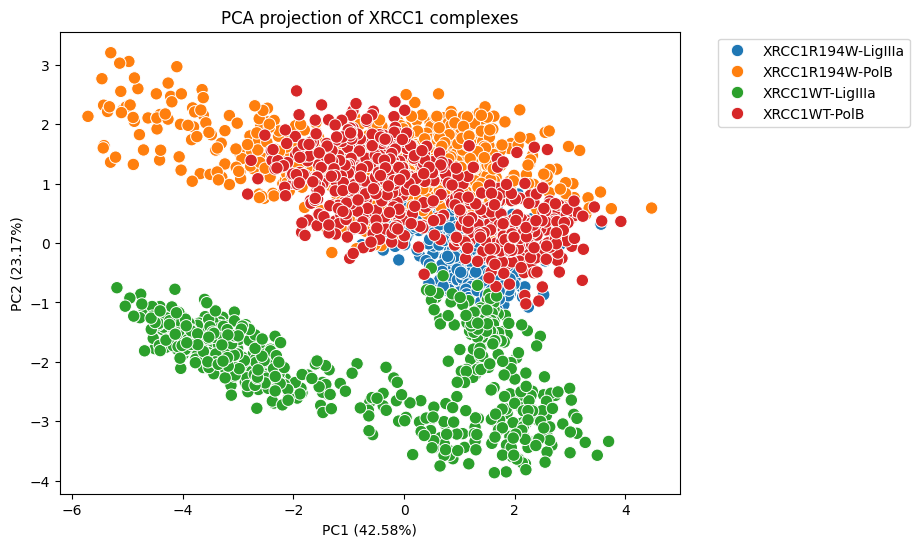

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="System",
    s=80
)

plt.title("PCA projection of XRCC1 complexes")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
)

plt.legend(bbox_to_anchor=(1.05,1))

plt.show()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42
)


rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=500, random_state=42)

In [ ]:
!python --version

Python 3.12.13


In [ ]:
prediction = rf.predict(X_test)


print(
    accuracy_score(
        y_test,
        prediction
    )
)


print(
classification_report(
    y_test,
    prediction
)
)

0.9733777038269551
                    precision    recall  f1-score   support

XRCC1R194W-LigIIIa       0.97      0.99      0.98       150
   XRCC1R194W-PolB       0.96      0.94      0.95       150
   XRCC1WT-LigIIIa       1.00      1.00      1.00       151
      XRCC1WT-PolB       0.96      0.96      0.96       150

          accuracy                           0.97       601
         macro avg       0.97      0.97      0.97       601
      weighted avg       0.97      0.97      0.97       601



In [ ]:
importance = pd.DataFrame({

    "Feature":features,

    "Importance":
    rf.feature_importances_

})


importance = importance.sort_values(
    "Importance",
    ascending=False
)


importance

,Feature,Importance
1,Rg,0.305801
0,RMSD,0.177333
2,SASA,0.157491
4,HBonds,0.150323
7,SA,0.066909
3,Contacts,0.057949
5,MM,0.032065
8,DGbinding,0.029022
6,PB,0.023107


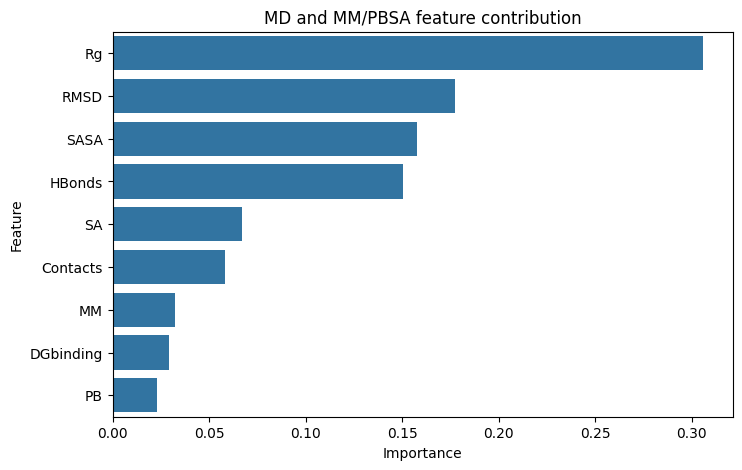

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
"MD and MM/PBSA feature contribution"
)

plt.show()